# Performing OCR for Hindi Digits from 0 to 9

## Importing all the required files

In [1]:
# Normal ML data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File manipulation
import os
import pickle

# Image manipulation
from skimage.io import imread
from skimage.transform import resize
import cv2

# ML Training and evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix

## Preprocessing by loading the data

### Training Data

In [2]:
datadir = "C:/Users/hites/My J Notebooks/My ML Codes/Hindi OCR_incomp/DevanagariHandwrittenCharacterDataset/Train"

categories = np.array(range(0,10,1))
target = []
flat_data = []

for i in categories:
    path = os.path.join(datadir,f'digit_{i}') # Copying path of a specific image
    for img in os.listdir(path):
        img_array = imread(os.path.join(path,img)) # Taking input of image as an array

        flat_data.append(np.ndarray.flatten(img_array)) # Storing image in the form of flattened array
        target.append(i) # Storing its corresponding category

# Converting to numpy array form
flat_data = np.array(flat_data)
target = np.array(target)

In [3]:
df_train = pd.DataFrame(flat_data)
df_train['Target'] = target

# Saving the preprocessed data as a CSV file
df_train.to_csv(r'C:/Users/hites/My J Notebooks/My ML Codes/Hindi OCR_incomp/Train.csv', index = False)
df_train.shape

(17000, 1025)

In [4]:
df_train

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
16996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
16997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
16998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [5]:
x_train = df_train.drop(columns='Target')
y_train = df_train['Target']

### Testing Data

In [6]:
datadir_test = "C:/Users/hites/My J Notebooks/My ML Codes/Hindi OCR_incomp/DevanagariHandwrittenCharacterDataset/Test"

target_test = []
flat_data_test = []

for i in categories:
    path = os.path.join(datadir_test,f'digit_{i}') # Copying path of a specific image
    for img in os.listdir(path):
        img_array_test = imread(os.path.join(path,img)) # Taking input of image as an array

        flat_data_test.append(np.ndarray.flatten(img_array_test)) # Storing image in the form of flattened array
        target_test.append(i) # Storing its corresponding category

# Converting to numpy array form
flat_data_test = np.array(flat_data_test)
target_test = np.array(target_test)

In [7]:
df_test = pd.DataFrame(flat_data_test)
df_test['Target'] = target_test

# Saving the preprocessed data as a CSV file
df_test.to_csv(r'C:/Users/hites/My J Notebooks/My ML Codes/Hindi OCR_incomp/Test.csv', index = False)

df_test.shape

(3000, 1025)

In [8]:
x_test = df_test.drop(columns='Target')
y_test = df_test['Target']

## Model Building and Evaluation

### Building a New Model

In [9]:
numModel = svm.SVC()
numModel.fit(x_train,y_train)

SVC()

In [10]:
# save the model to disk
filename = 'Mini_Project_model.sav'
pickle.dump(numModel, open(filename, 'wb'))

In [11]:
numPrd = numModel.predict(x_test)

Text(0.5, 1.0, 'Confusion Matrix of the New Model')

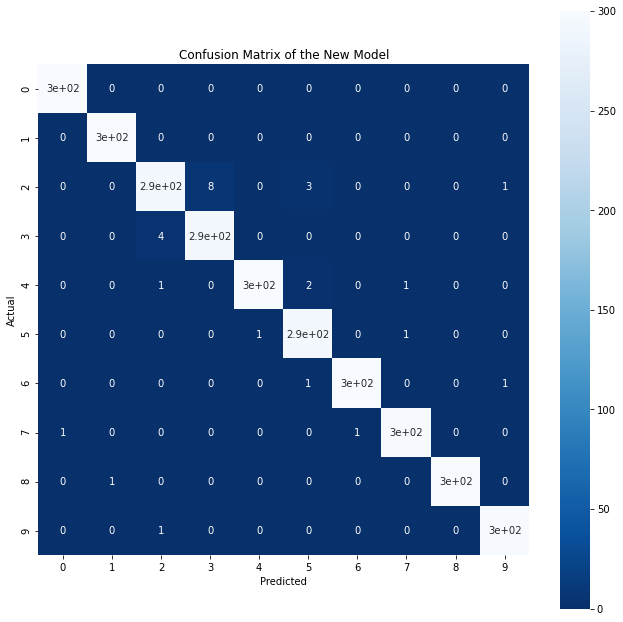

In [12]:
plt.figure(figsize=(11,11))
sns.heatmap(confusion_matrix(numPrd,y_test), annot=True, square = True, cmap='Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');
plt.title('Confusion Matrix of the New Model')

In [13]:
print(classification_report(numPrd,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       299
           2       0.98      0.96      0.97       306
           3       0.97      0.99      0.98       296
           4       1.00      0.99      0.99       303
           5       0.98      0.99      0.99       296
           6       1.00      0.99      1.00       301
           7       0.99      0.99      0.99       300
           8       1.00      1.00      1.00       301
           9       0.99      1.00      0.99       299

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



### Loading a previously saved model

In [14]:
# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))

In [15]:
ldPrd = loaded_model.predict(x_test)

Text(0.5, 1.0, 'Confusion Matrix of the Loaded Model')

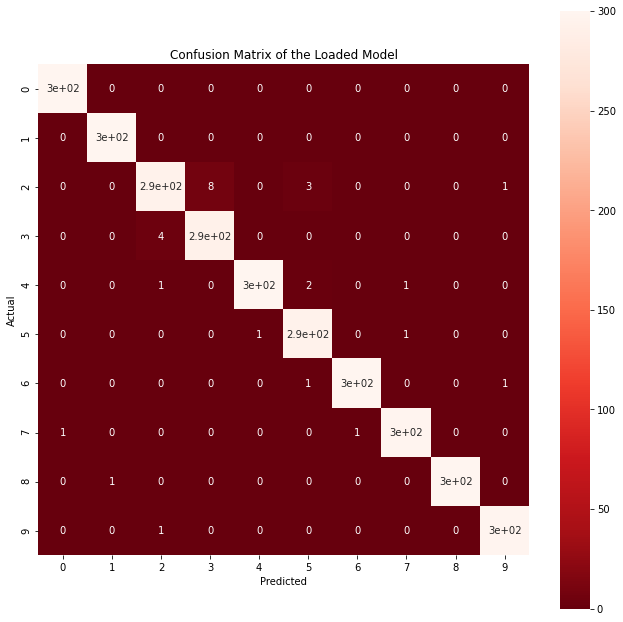

In [16]:
plt.figure(figsize=(11,11))
sns.heatmap(confusion_matrix(ldPrd,y_test), annot=True, square = True, cmap='Reds_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');
plt.title('Confusion Matrix of the Loaded Model')

In [17]:
print(classification_report(ldPrd,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       299
           2       0.98      0.96      0.97       306
           3       0.97      0.99      0.98       296
           4       1.00      0.99      0.99       303
           5       0.98      0.99      0.99       296
           6       1.00      0.99      1.00       301
           7       0.99      0.99      0.99       300
           8       1.00      1.00      1.00       301
           9       0.99      1.00      0.99       299

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



## Hyperparameter Tuning with Grid Search

Extensive tuning was performed beforehand which got us the value as {'C': 25, 'kernel': 'rbf'}\
This is just a simulation to show how it was performed.

In [18]:
from datetime import datetime

bfre = datetime.now()
current_time = bfre.strftime("%H:%M:%S")
print("Before Grid Search: ", current_time)

model = svm.SVC(kernel='rbf')
max = 36
min = 25
step = 5

param = {
    # 'kernel':['linear','rbf','poly'],
    'C': np.array(range(min,max,step)),
}

grid = GridSearchCV(model, param, cv=3, verbose=2)
grid.fit(x_train,y_train)

aftr = datetime.now()
current_time = aftr.strftime("%H:%M:%S")
print("After Grid Search: ", current_time)

grid.best_params_

Before Grid Search:  18:17:24
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] C=25 ............................................................


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] ............................................. C=25, total= 2.2min
[CV] C=25 ............................................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.2min remaining:    0.0s


[CV] ............................................. C=25, total= 1.7min
[CV] C=25 ............................................................
[CV] ............................................. C=25, total= 1.9min
[CV] C=30 ............................................................
[CV] ............................................. C=30, total= 2.1min
[CV] C=30 ............................................................
[CV] ............................................. C=30, total= 1.8min
[CV] C=30 ............................................................
[CV] ............................................. C=30, total= 1.7min
[CV] C=35 ............................................................
[CV] ............................................. C=35, total= 2.2min
[CV] C=35 ............................................................
[CV] ............................................. C=35, total= 1.6min
[CV] C=35 ............................................................
[CV] .

[Parallel(n_jobs=1)]: Done   9 out of   9 | elapsed: 16.7min finished


After Grid Search:  18:35:49


{'C': 25}

In [19]:
gridPrd = grid.predict(x_test)

Text(0.5, 1.0, 'Confusion Matrix of the Tuned Model')

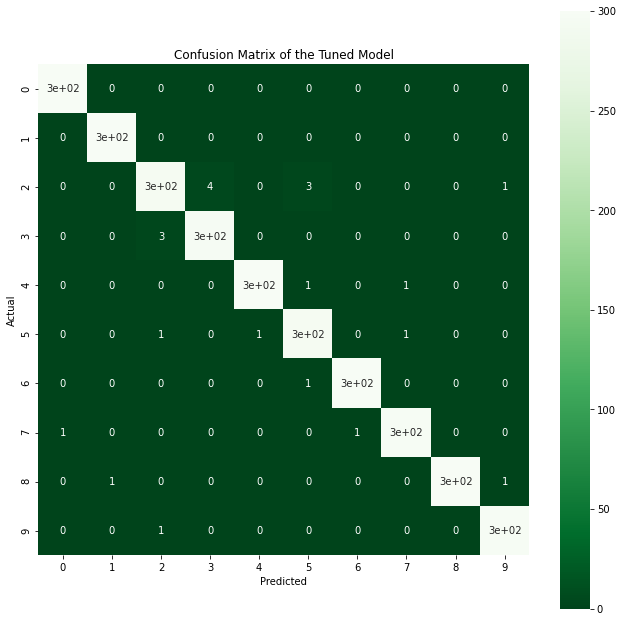

In [20]:
plt.figure(figsize=(11,11))
sns.heatmap(confusion_matrix(gridPrd,y_test), annot=True, square = True, cmap='Greens_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');
plt.title('Confusion Matrix of the Tuned Model')

In [21]:
print(classification_report(gridPrd,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       299
           2       0.98      0.97      0.98       303
           3       0.99      0.99      0.99       299
           4       1.00      0.99      1.00       301
           5       0.98      0.99      0.99       298
           6       1.00      1.00      1.00       300
           7       0.99      0.99      0.99       300
           8       1.00      0.99      1.00       302
           9       0.99      1.00      0.99       299

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



### Saving the tuned model

In [22]:
# save the model to disk
filename = 'Mini_Project_best_model.sav'
pickle.dump(grid, open(filename, 'wb'))